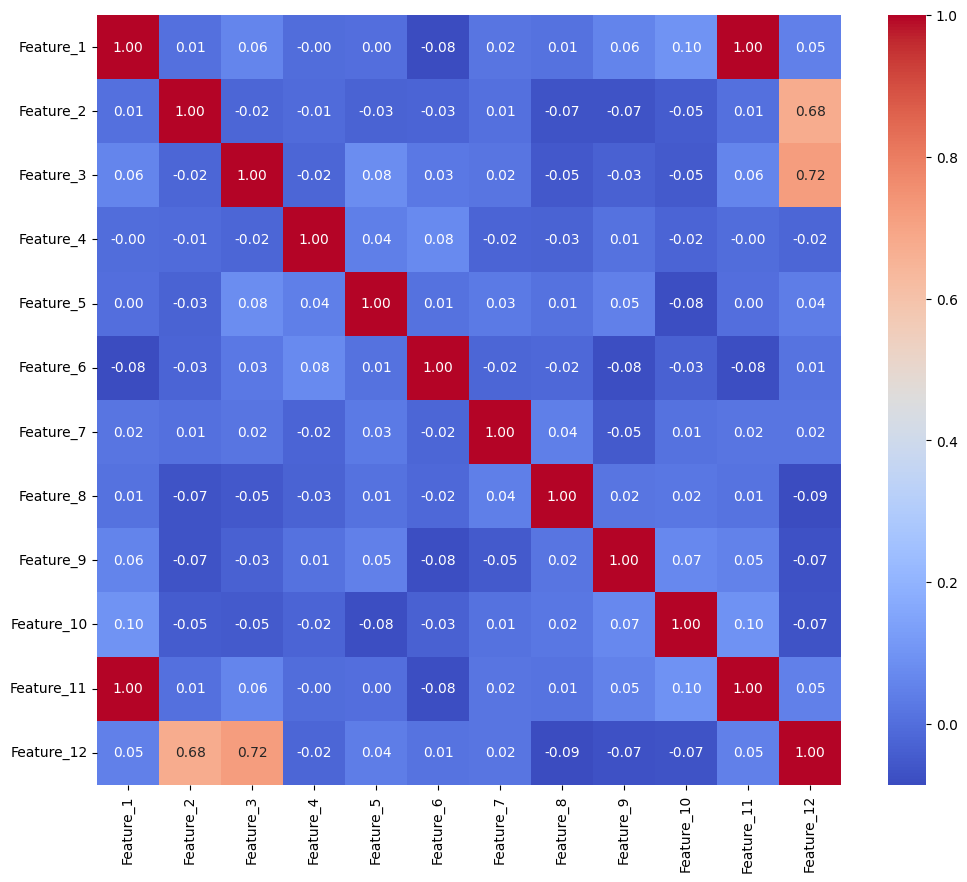

Initial VIF Factors:
      Variable         VIF
1    Feature_1  382.629215
11  Feature_11  382.224285
12  Feature_12  209.715699
3    Feature_3  114.079307
2    Feature_2  101.285100
6    Feature_6    1.047190
9    Feature_9    1.032695
10  Feature_10    1.031545
5    Feature_5    1.019938
8    Feature_8    1.011956
4    Feature_4    1.011036
7    Feature_7    1.010469

VIF Factors after removing collinear features:
     Variable       VIF
1   Feature_4  1.009455
2   Feature_5  1.012650
3   Feature_6  1.013237
4   Feature_7  1.006742
5   Feature_8  1.003987
6   Feature_9  1.017015
7  Feature_10  1.013614

Full Model R2 Score: 0.9684
Reduced Model R2 Score: 0.8206


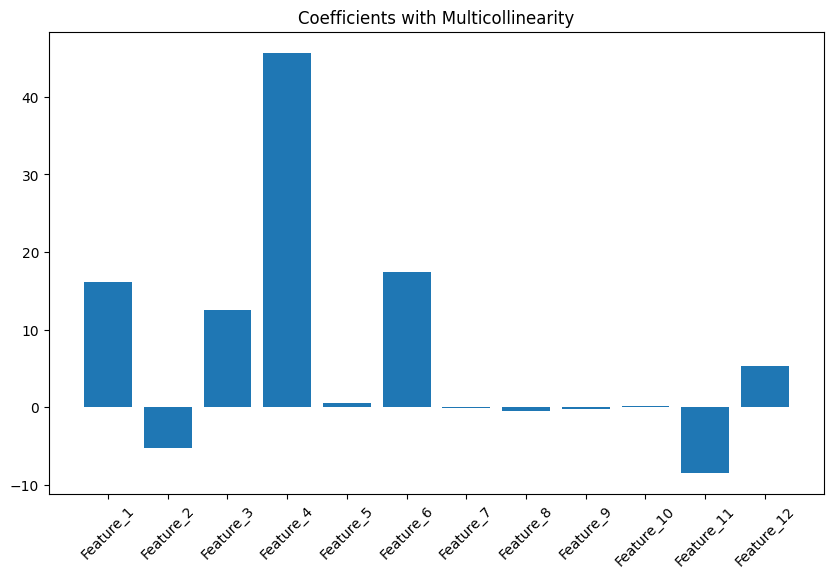

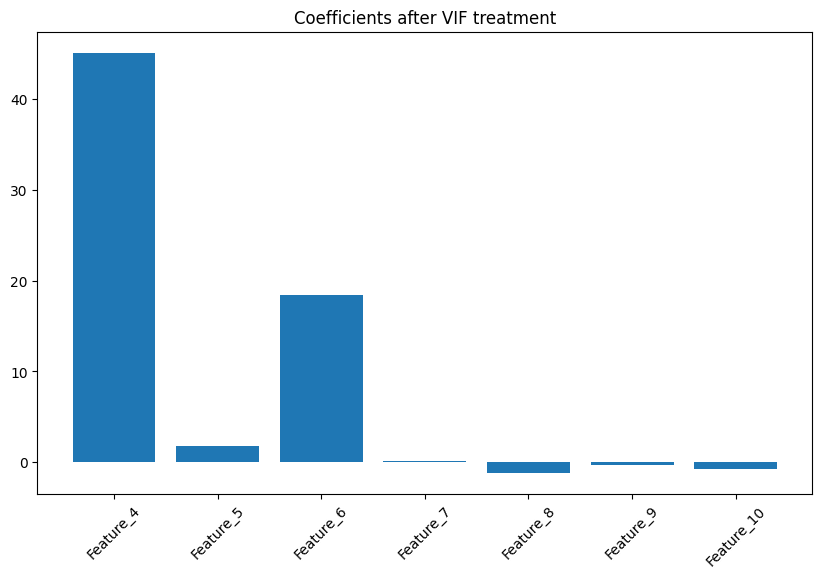

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X, y = make_regression(n_samples=500, n_features=10, n_informative=3, noise=10, random_state=42)
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 11)])

df['Feature_11'] = df['Feature_1'] * 2 + np.random.normal(0, 0.1, 500)
df['Feature_12'] = df['Feature_2'] + df['Feature_3'] + np.random.normal(0, 0.1, 500)

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

def calculate_vif(data):
    vif_df = pd.DataFrame()
    X_vif = add_constant(data)
    vif_df["Variable"] = X_vif.columns
    vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    return vif_df.drop(index=0)

vif_results = calculate_vif(df)
print("Initial VIF Factors:")
print(vif_results.sort_values(by="VIF", ascending=False))

high_vif_features = vif_results[vif_results['VIF'] > 10]['Variable'].tolist()
df_reduced = df.drop(columns=high_vif_features)

vif_reduced = calculate_vif(df_reduced)
print("\nVIF Factors after removing collinear features:")
print(vif_reduced)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)
model_full = LinearRegression()
model_full.fit(X_train, y_train)
print(f"\nFull Model R2 Score: {model_full.score(X_test, y_test):.4f}")

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(df_reduced, y, test_size=0.2, random_state=42)
model_reduced = LinearRegression()
model_reduced.fit(X_train_r, y_train_r)
print(f"Reduced Model R2 Score: {model_reduced.score(X_test_r, y_test_r):.4f}")

plt.figure(figsize=(10, 6))
plt.bar(df.columns, model_full.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients with Multicollinearity")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(df_reduced.columns, model_reduced.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients after VIF treatment")
plt.show()